# Lab 5: Clustering
---

Q1. You are given the following 2D data points. Apply K-Means clustering and use the Elbow Method to determine the optimal number of clusters.
[1, 2], [2, 3], [3, 3], [10, 12], [11, 13], [12, 14],[25, 30], [26, 29], [27, 28]

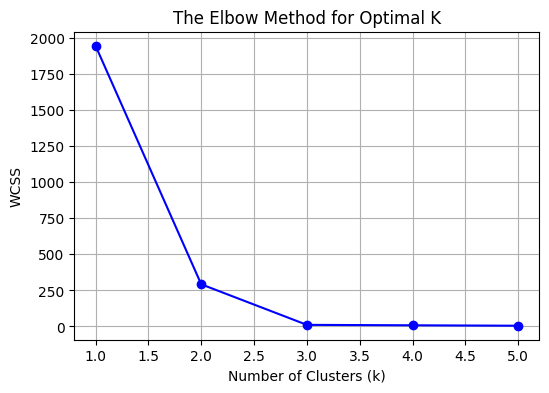

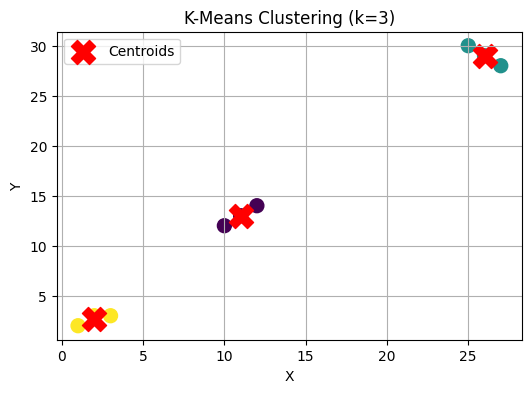

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Given 2D data points
X1 = np.array([
    [1, 2], [2, 3], [3, 3], 
    [10, 12], [11, 13], [12, 14], 
    [25, 30], [26, 29], [27, 28]
])

# Elbow Method to find optimal k i.e. clusters
wcss = []
k_range = range(1, 6)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Based on the data distribution and typical elbow graph, optimal k = 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X1)

# Plotting the K-Means clusters
plt.figure(figsize=(6, 4))
plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

Q2. Perform agglomerative hierarchical clustering on the following data points. Plot the dendrogram and identify the optimal number of clusters.
[1, 1], [2, 1], [1, 2], [8, 8], [9, 9], [8, 9], [4, 7], [5, 6]

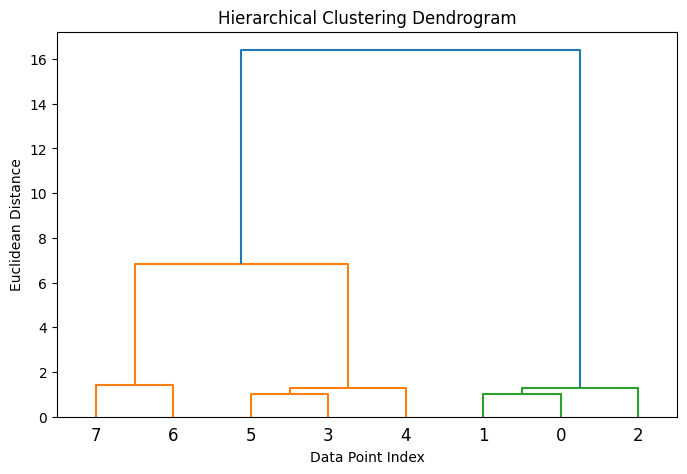

Agglomerative Cluster Assignments: [1 1 1 2 2 2 0 0]


In [2]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Given data points
X2 = np.array([
    [1, 1], [2, 1], [1, 2], 
    [8, 8], [9, 9], [8, 9], 
    [4, 7], [5, 6]
])

# Compute linkage matrix using Ward's method
linked = linkage(X2, method='ward')

# Plotting the Dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Point Index')
plt.ylabel('Euclidean Distance')
plt.show()

# Applying Agglomerative Clustering (based on dendrogram, optimal clusters = 3)
optimal_clusters_hc = 3
hc = AgglomerativeClustering(n_clusters=optimal_clusters_hc, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X2)

print(f"Agglomerative Cluster Assignments: {y_hc}")

Q3. Apply the DBSCAN algorithm to find core, border, and noise points from the
following spatial dataset.
[1, 2], [1.1, 2.1], [0.9, 1.8], [1.2, 2.2], [8, 8], [8.1, 8.2], [8.2, 7.9], [5, 5]

In [3]:
from sklearn.cluster import DBSCAN

# Given spatial dataset
X3 = np.array([
    [1, 2], [1.1, 2.1], [0.9, 1.8], [1.2, 2.2], 
    [8, 8], [8.1, 8.2], [8.2, 7.9], 
    [5, 5]  
])

# Apply DBSCAN (eps=0.5, min_samples=2)
dbscan = DBSCAN(eps=0.5, min_samples=2)
dbscan.fit(X3)

labels = dbscan.labels_
core_sample_indices = dbscan.core_sample_indices_

print("Cluster Labels for each point:", labels)
print("Indices of Core Points:", core_sample_indices)

# Detailed classification interpretation
for i, point in enumerate(X3):
    if i in core_sample_indices:
        pt_type = "Core Point"
    elif labels[i] != -1:
        pt_type = "Border Point"
    else:
        pt_type = "Noise Point"
    
    print(f"Point {point} -> Label: {labels[i]} ({pt_type})")

Cluster Labels for each point: [ 0  0  0  0  1  1  1 -1]
Indices of Core Points: [0 1 2 3 4 5 6]
Point [1. 2.] -> Label: 0 (Core Point)
Point [1.1 2.1] -> Label: 0 (Core Point)
Point [0.9 1.8] -> Label: 0 (Core Point)
Point [1.2 2.2] -> Label: 0 (Core Point)
Point [8. 8.] -> Label: 1 (Core Point)
Point [8.1 8.2] -> Label: 1 (Core Point)
Point [8.2 7.9] -> Label: 1 (Core Point)
Point [5. 5.] -> Label: -1 (Noise Point)


# Reflection of the DBSCAN clustering results: 

> This algorithm partitioned the spatial dataset into 2 clusters while identifying the noise/outlier. Points labeled as 0 and 1 represent the dense regions where every single point acts as a core point meaning they all have the required minimum numbers of neighbours which was 2 here in my code and this neighbour should be within 0.5 radius. 